In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df= pd.read_csv('business_revenue_prediction_dataset_v1.csv')
print(df.head())

   MarketingSpend  WebsiteVisits  ConversionRate  CustomerSatisfaction  \
0         8116.26           8305            5.89                  70.7   
1        19063.57           5737            5.27                  54.3   
2        14907.88          20556            3.64                  99.8   
3        12374.51          46043            1.15                  75.1   
4         3964.35          49512           10.44                  79.8   

   AvgOrderValue  ReturnRate  RepeatCustomerRate  DeliveryTime  SeasonalIndex  \
0         410.80        7.33               63.10           7.0           0.95   
1         417.75        7.92               54.60           6.7           0.93   
2         258.66       13.91               18.89           2.5           0.90   
3          13.13        7.77               18.06           8.9           0.83   
4         150.65        8.97               12.38           4.8           0.97   

   MonthlyRevenue  
0        13362.04  
1        14183.89  
2       

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MarketingSpend        320 non-null    float64
 1   WebsiteVisits         320 non-null    int64  
 2   ConversionRate        320 non-null    float64
 3   CustomerSatisfaction  320 non-null    float64
 4   AvgOrderValue         320 non-null    float64
 5   ReturnRate            320 non-null    float64
 6   RepeatCustomerRate    320 non-null    float64
 7   DeliveryTime          320 non-null    float64
 8   SeasonalIndex         320 non-null    float64
 9   MonthlyRevenue        320 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 25.1 KB
None


In [4]:
print(df.describe())

       MarketingSpend  WebsiteVisits  ConversionRate  CustomerSatisfaction  \
count      320.000000     320.000000      320.000000            320.000000   
mean     10378.637813   25623.112500        6.081969             74.934375   
std       5592.463069   13913.678755        3.247352             14.809404   
min       1096.170000     509.000000        0.550000             50.500000   
25%       5542.537500   13955.750000        3.215000             61.575000   
50%      10722.640000   25820.000000        5.935000             74.950000   
75%      15226.372500   37729.750000        8.917500             88.250000   
max      19811.020000   49907.000000       12.000000             99.900000   

       AvgOrderValue  ReturnRate  RepeatCustomerRate  DeliveryTime  \
count      320.00000  320.000000          320.000000    320.000000   
mean       258.94750    9.751563           43.173187      5.421562   
std        146.07731    5.717888           21.617458      2.552226   
min         12.42

In [5]:
print(df.isnull().sum())

MarketingSpend          0
WebsiteVisits           0
ConversionRate          0
CustomerSatisfaction    0
AvgOrderValue           0
ReturnRate              0
RepeatCustomerRate      0
DeliveryTime            0
SeasonalIndex           0
MonthlyRevenue          0
dtype: int64


In [6]:
X = df.drop('MonthlyRevenue', axis=1)   
y = df['MonthlyRevenue']   

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")



Training data shape: (256, 9)
Testing data shape: (64, 9)


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr= lr_model.predict(X_test)
mse_lr= mean_squared_error(y_test, y_pred_lr)
r2_lr= r2_score(y_test, y_pred_lr)

print('Linear Regression:')
print('MSE:', mse_lr)
print('R2 Score:', r2_lr)

Linear Regression:
MSE: 1579149.3730100722
R2 Score: 0.8968439023997797


In [8]:
dt_model= DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
y_pred_dt= dt_model.predict(X_test)
mse_dt= mean_squared_error(y_test, y_pred_dt)
r2_dt= r2_score(y_test, y_pred_dt)

print('\nDecision Tree:')
print('MSE:', mse_dt)
print('R2 Score:', r2_dt)


Decision Tree:
MSE: 6396073.102923438
R2 Score: 0.5821839576799137


In [10]:
print('\nComparison:')
print(f'Linear Regression R2: {r2_lr}')
print(f'Decision Tree R2: {r2_dt}')


Comparison:
Linear Regression R2: 0.8968439023997797
Decision Tree R2: 0.5821839576799137


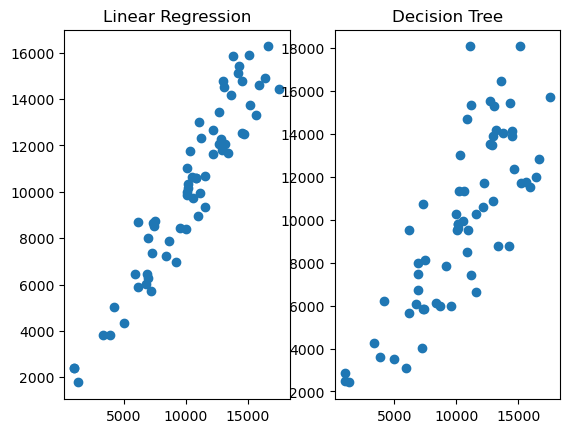

In [11]:
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr)
plt.title('Linear Regression')
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_dt)
plt.title('Decision Tree')
plt.show()